# Titanic Survival — Part 1a: Exploration & Preparation

This notebook covers the first half of the Part 1 workflow: getting to know the Titanic dataset and turning it into a clean input table for modeling. It is split into four sections:

1. **Loading & inspection** — shape, types, and a first look at the rows.
2. **Data quality** — missing values, duplicates, and consistency of the encoded columns.
3. **Visual exploration** — distributions, survival rates, and correlations.
4. **Preparation** — duplicate removal, light feature engineering, and writing the cleaned dataset to `data/titanic_clean.csv`.

The modeling and evaluation steps are continued in [`titanic_survival_part_1b.ipynb`](titanic_survival_part_1b.ipynb), which loads the cleaned CSV produced here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RAW_PATH = "../data/titanic.csv"
CLEAN_PATH = "../data/titanic_clean.csv"

## 1. Loading & inspection

We load the CSV and look at the shape, the first rows, and the column dtypes. This is the cheapest way to sanity-check that the file matches our expectations before going deeper.

In [2]:
data = pd.read_csv(RAW_PATH)

print(f"Shape: {data.shape}")
data.head()

Shape: (887, 8)


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


`describe()` gives the central tendencies and ranges of every column. It is a quick way to spot suspicious values such as negative ages or extreme fares.

In [4]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sex,887.0,0.65,0.48,0.00,0.00,1.00,1.00,1.00
age,887.0,29.47,14.12,0.42,20.25,28.00,38.00,80.00
family_size,887.0,0.91,1.62,0.00,0.00,0.00,1.00,10.00
fare,887.0,32.31,49.78,0.00,7.92,14.45,31.14,512.33
1st_class,887.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
2nd_class,887.0,0.21,0.41,0.00,0.00,0.00,0.00,1.00
3rd_class,887.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
survived,887.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00


## 2. Data quality

We check for the issues that most often cause silent bugs downstream:

- missing values,
- duplicate rows,
- invalid values in the binary / one-hot-encoded columns,
- unexpected values in the continuous columns.

In [5]:
print("Missing values per column:")
print(data.isna().sum())

Missing values per column:
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64


In [6]:
n_dup = data.duplicated().sum()
print(f"Duplicate rows: {n_dup}  ({n_dup / len(data):.1%} of total)")

Duplicate rows: 70  (7.9% of total)


In [7]:
binary_cols = ["sex", "survived", "1st_class", "2nd_class", "3rd_class"]
for col in binary_cols:
    invalid = (~data[col].isin([0, 1])).sum()
    print(f"{col:>10s}: unique = {sorted(data[col].unique())}, invalid = {invalid}")

one_hot_ok = (data[["1st_class", "2nd_class", "3rd_class"]].sum(axis=1) == 1).all()
print(f"\nEvery row belongs to exactly one class column: {one_hot_ok}")

       sex: unique = [np.int64(0), np.int64(1)], invalid = 0
  survived: unique = [np.int64(0), np.int64(1)], invalid = 0
 1st_class: unique = [np.int64(0), np.int64(1)], invalid = 0
 2nd_class: unique = [np.int64(0), np.int64(1)], invalid = 0
 3rd_class: unique = [np.int64(0), np.int64(1)], invalid = 0

Every row belongs to exactly one class column: True


In [8]:
for col in ["age", "family_size", "fare"]:
    print(f"{col}:")
    print(f"  negative values: {(data[col] < 0).sum()}")
    print(f"  unique values:   {data[col].nunique()}")
    if col == "family_size":
        print(f"  values seen:     {sorted(data[col].unique())}")
    else:
        print(f"  unique after floor: {data[col].apply(np.floor).nunique()}")
    print()

age:
  negative values: 0
  unique values:   89
  unique after floor: 72

family_size:
  negative values: 0
  unique values:   9
  values seen:     [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10)]

fare:
  negative values: 0
  unique values:   248
  unique after floor: 91



**Findings**

- **No missing values.** 
- **70 duplicate rows (~8%).** Keeping these would give some passengers more weight than others during training, so we drop them in the preparation step.
- **`age` has 17 fractional values.** In this dataset fractions encode months (e.g. `0.42` = 5 months). Modeling will work either way, but flooring to integer years gives a cleaner, more interpretable feature.
- **The three class columns are a clean one-hot encoding** (every row sums to 1). This makes the third column linearly dependent on the other two — keeping all three would introduce perfect multicollinearity, so we drop one of them in the preparation step.

## 3. Visual exploration

Numbers tell us *what* is in the data; plots tell us *how* it relates to the target. We visualize the target balance, the feature distributions split by survival, the survival rate per categorical feature, and the pairwise correlations.

### Target distribution

About 39% of passengers survived. That is mildly imbalanced — enough that we should not rely on accuracy alone when evaluating the model later.

Died:     545
Survived: 342
Survival rate: 38.56%


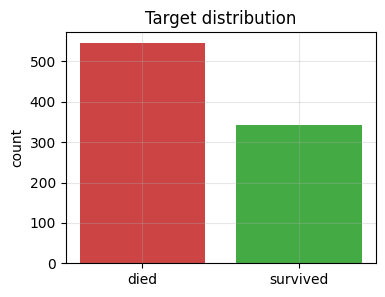

In [9]:
counts = data["survived"].value_counts().sort_index()
print(f"Died:     {counts[0]}")
print(f"Survived: {counts[1]}")
print(f"Survival rate: {data['survived'].mean():.2%}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["died", "survived"], counts.values, color=["#c44", "#4a4"])
ax.set(ylabel="count", title="Target distribution")
plt.show()

### Continuous features by survival

Stacked histograms of `age`, `fare`, and `family_size` split by survival. Where the green (survived) layer dominates a bin, that range of the feature is associated with survival; where the red (died) layer dominates, with not surviving.

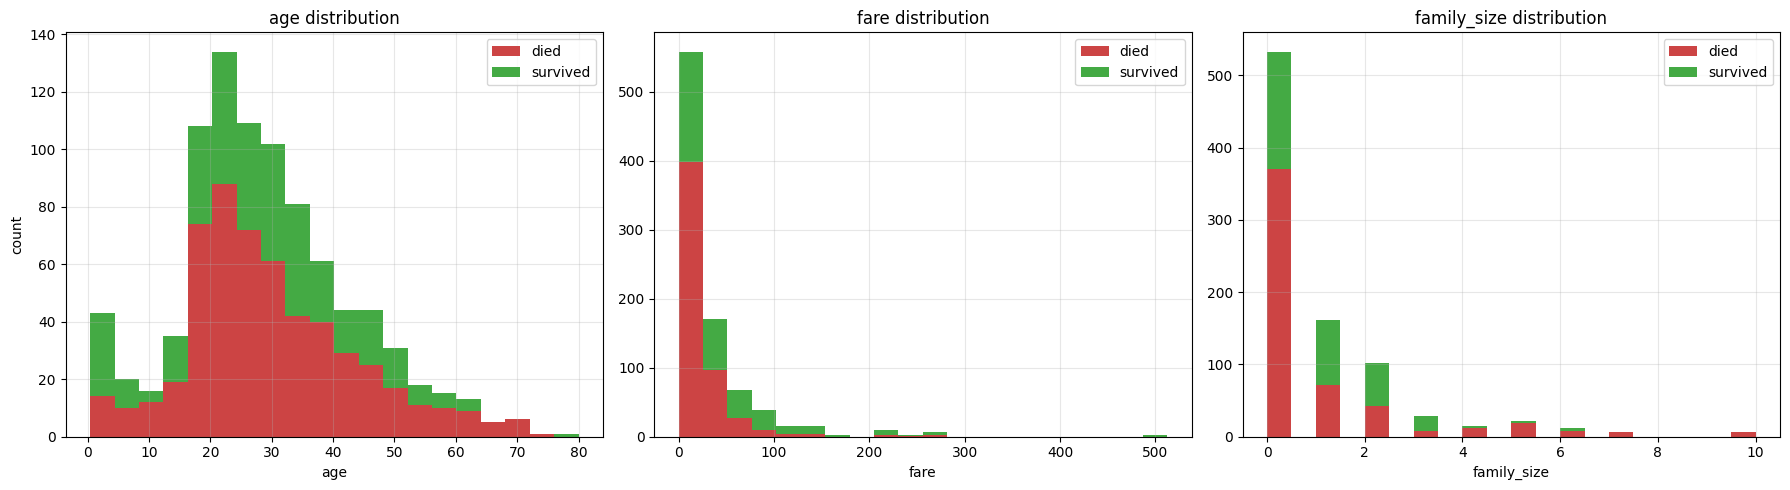

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["age", "fare", "family_size"]):
    ax.hist(
        [data.loc[data["survived"] == 0, col], data.loc[data["survived"] == 1, col]],
        bins=20,
        stacked=True,
        label=["died", "survived"],
        color=["#c44", "#4a4"],
    )
    ax.set(title=f"{col} distribution", xlabel=col)
    ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

### Survival rate by categorical feature

For categorical features the survival *rate* is more informative than a histogram. We compute it for `sex` and for `ticket class`.

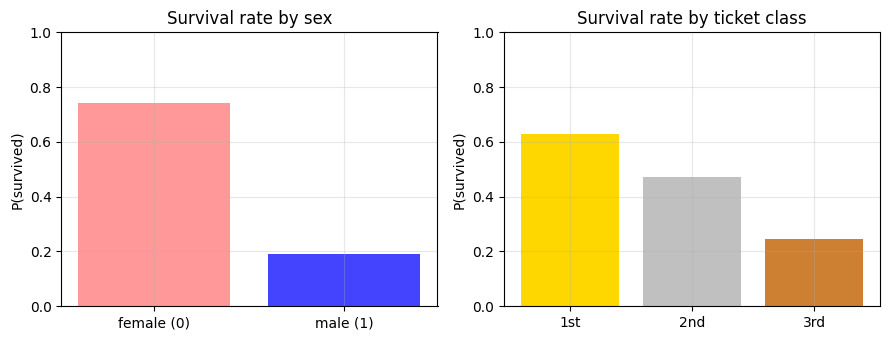

In [11]:
by_sex = data.groupby("sex")["survived"].mean()
by_class = pd.Series(
    {
        "1st": data.loc[data["1st_class"] == 1, "survived"].mean(),
        "2nd": data.loc[data["2nd_class"] == 1, "survived"].mean(),
        "3rd": data.loc[data["3rd_class"] == 1, "survived"].mean(),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(["female (0)", "male (1)"], by_sex.values, color=["#f99", "#44f"])
axes[0].set_title("Survival rate by sex")
axes[1].bar(by_class.index, by_class.values, color=["#ffd700", "#c0c0c0", "#cd7f32"])
axes[1].set_title("Survival rate by ticket class")
for ax in axes:
    ax.set_ylabel("P(survived)")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Correlation matrix

A heatmap of Pearson correlations highlights features that move with the target as well as features that are linearly dependent on each other.

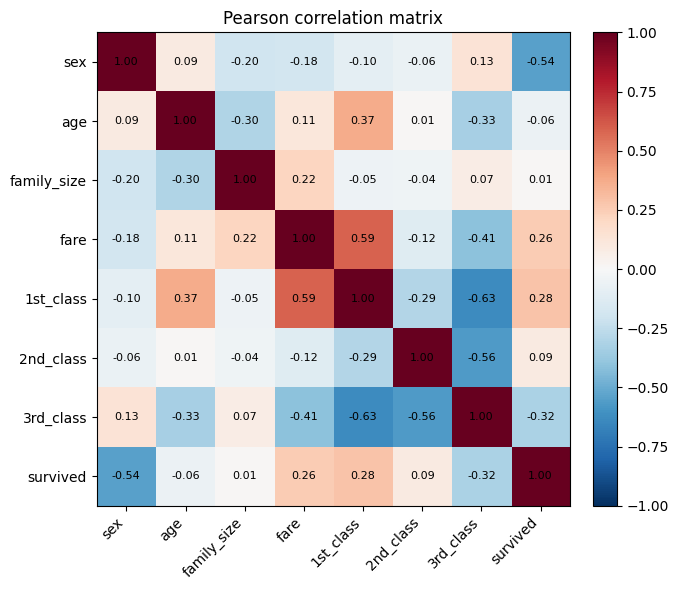

In [12]:
corr = data.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.grid(False)
ax.set_title("Pearson correlation matrix")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

**Take-aways from exploration**

- `sex` has the strongest single relationship with survival: females survived at a much higher rate than males.
- Ticket class matters: 1st-class passengers survived ~63%, 3rd-class only ~24%.
- `fare` is positively correlated with survival, but it is also strongly correlated with `1st_class`. Its independent signal is therefore limited; we keep things simple and leave it out of the model.
- `age` and `family_size` carry weaker but still visible signal — younger passengers and small families survived slightly more often.
- The class columns are perfectly collinear by construction, so we drop one of them in preparation.

## 4. Preparation

Based on the exploration we apply the following transformations:

1. **Drop duplicate rows** so no passenger is double-counted.
2. **Floor `age`** to integer years, fixing the fractional infant encoding.
3. **Bucket `family_size`** into a binary `family_size_lt4` indicator. The raw column is heavily skewed (a handful of very large families pull the mean up); a binary split at 4 captures the "small family" effect without letting the long tail dominate the linear model.
4. **Drop `3rd_class`** as the reference category, removing the perfect collinearity of the one-hot encoding.
5. **Drop `fare`** — its signal is largely already in `1st_class`/`2nd_class` and we want a small, interpretable feature set.
6. **Save the cleaned dataset** to `data/titanic_clean.csv` for the modeling notebook to consume.

Note that we do *not* split into train/test or scale features here — those steps belong with the model and live in [`titanic_survival_part_1b.ipynb`](`titanic_survival_part_1b.ipynb`).

In [13]:
clean = data.drop_duplicates().copy()
print(f"Rows: {len(data)} -> {len(clean)} after dropping duplicates")

clean["age"] = np.floor(clean["age"]).astype(int)
clean["family_size_lt4"] = (clean["family_size"] < 4).astype(int)

clean = clean.drop(columns=["family_size", "fare", "3rd_class"])

clean.head()

Rows: 887 -> 817 after dropping duplicates


,sex,age,1st_class,2nd_class,survived,family_size_lt4
0,1,22,0,0,0,1
1,0,38,1,0,1,1
2,0,26,0,0,1,1
3,0,35,1,0,1,1
4,1,35,0,0,0,1


In [14]:
clean.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sex,817.0,0.63,0.48,0.0,0.0,1.0,1.0,1.0
age,817.0,29.68,14.49,0.0,20.0,28.0,39.0,80.0
1st_class,817.0,0.26,0.44,0.0,0.0,0.0,1.0,1.0
2nd_class,817.0,0.21,0.40,0.0,0.0,0.0,0.0,1.0
survived,817.0,0.40,0.49,0.0,0.0,0.0,1.0,1.0
family_size_lt4,817.0,0.92,0.26,0.0,1.0,1.0,1.0,1.0


In [15]:
clean.to_csv(CLEAN_PATH, index=False)
print(f"Cleaned dataset written to {CLEAN_PATH}  (shape: {clean.shape})")

Cleaned dataset written to ../data/titanic_clean.csv  (shape: (817, 6))


Continue in [`titanic_survival_part_1b.ipynb`](titanic_survival_part_1b.ipynb) to train and evaluate the logistic-regression model on this cleaned dataset.